# **Static Deep Learning for K. pneumoniae on DRIAMS set A with the longskip architecure and bayesian network**

## **Import the necessary libraries**

In [1]:
import os

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # must be set before torch is imported
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"


In [2]:
#utilities
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from collections import defaultdict
import copy
import re
import json
import umap
import shap
from tqdm import tqdm


# data splitting, metrics calculation
from skmultilearn.model_selection import IterativeStratification
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    hamming_loss,
    confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import MinMaxScaler

# model training
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.nn import BCELoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

2025-09-27 15:10:10.970103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758985811.312025      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758985811.402834      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## **Importing torchbnn for bayesian network**

In [3]:
!pip install torchbnn
import torchbnn as bnn

## **Seed for reproducibility**

In [4]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    torch.set_float32_matmul_precision('high')


SEED = 3
seed_everything(3)

# **Utility Functions**

## **Function to make specific specie-antibiotic datasets**

This function reads a CSV file containing MALDI-TOF spectra and metadata, extracts numeric features (spectral bins), and filters the data for a specific bacterial species and selected antibiotics. It performs the following:
- Selects only rows corresponding to the target species.
- Filters out antibiotic columns that are not available or contain only NaNs.
- Combines spectral features with susceptibility labels for valid antibiotics.
- Removes rows with invalid or missing labels (only 'R', 'S', or 'I' are retained).

Returns a cleaned DataFrame ready for downstream AMR modeling.


In [5]:
def generate_driam_sets(specie, antibiotics, file_path, output_path = ""):
    """
    Extracts and prepares MALDI-TOF mass spectra and antibiotic resistance labels 
    for a given bacterial species from a DRIAM CSV file.

    Args:
        specie (str): Target bacterial species to extract.
        antibiotics (List[str]): List of antibiotic names to extract resistance labels for.
        file_path (str): Path to the input CSV file containing the DRIAM dataset.
        output_path (str, optional): Directory to save output files (not used here). Defaults to "".

    Returns:
        pd.DataFrame or None: Trimmed dataframe containing mass spectra and labels for the species.
                              Returns None if no data is found or antibiotics are missing.
    """
    print("Processing file at", file_path)
    bacteria = pd.read_csv(file_path)
    #Dropong all column with atleast one non-numeric character to Extract the feature columns i.e the bins
    malditof = bacteria[bacteria.columns.drop(list(bacteria.filter(regex='[^0-9]')))]

    print(f"\nProcessing species: {specie} in file: {file_path}")
    # We extract the species under study
    filtered_bacteria = bacteria[bacteria["species"] == specie]

    # Skip gracefully if no species are found in the file
    if filtered_bacteria.empty:
        print(f"Skipping {specie} in {file_path}: No rows found for species.")
        return

    # We'll only use those antibiotics in the given antibiotics which are actually present for that specie in dataframe
    available_antibiotics = [ab for ab in antibiotics if ab in filtered_bacteria.columns]

    # if no antibiotic is available in file, then skip gracefully
    if not available_antibiotics:
        print(f"Skipping {specie} in {file_path}: None of the specified antibiotics found.")
        return


    # If the label column cells are empty, replace them with the NaN
    filtered_bacteria[available_antibiotics] = filtered_bacteria[available_antibiotics].replace('', np.nan)

    # Drop columns that are completely NaN
    filtered_bacteria.dropna(axis=1, how='all', inplace=True)

    # Again get the available antibiotics in updated filtered dataframe where we dropped NaN columns
    available_antibiotics = [ab for ab in available_antibiotics if ab in filtered_bacteria.columns]

    # Making the new dataframes by combining mass spectra and antibiotic columns
    trimmed_bac = pd.DataFrame(
        np.column_stack([malditof.loc[filtered_bacteria.index], filtered_bacteria[available_antibiotics]]),
        columns=list(malditof.columns) + available_antibiotics
        )

    # Drop rows where any antibiotic label is NOT 'R' or 'S'
    for ab in antibiotics:
        trimmed_bac = trimmed_bac[trimmed_bac[ab].isin(['R', 'S', 'I'])]

    # Also drop rows with NaNs in antibiotic columns
    trimmed_bac = trimmed_bac.dropna(subset=antibiotics)

    # Proceed with analysis
    return trimmed_bac


## **Multi-label Stratified Train-Test Split**

This function performs a train-test split while preserving label distributions across multiple antibiotic resistance labels using `IterativeStratification`. This is crucial for multi-label classification problems, where standard stratification is not sufficient.

The number of splits is derived from the test size, and the function returns indices for training and testing data.


In [6]:
# Function to do train/test split stratified multi-label
def multilabel_train_test_split(X, y, test_size=0.2):
    """
    Performs stratified multi-label train/test split using iterative stratification.

    Args:
        X (np.ndarray): Input feature matrix.
        y (np.ndarray): Binary multi-label matrix of shape (n_samples, n_labels).
        test_size (float): Proportion of data to include in the test split.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Indices for training and testing sets.
    """
    # Splitting the Multi-label dataset
    inv = 1 / test_size
    n_splits = max(2, int(round(inv)))  # Make sure it's at least 2
    stratifier = IterativeStratification(n_splits=n_splits, order=1)
    # Returning the train and test indices
    for train_idx, test_idx in stratifier.split(X, y):
        return train_idx, test_idx

## **Label Smoothing for Multi-label Targets**

Applies label smoothing to the binary ground-truth matrix. Instead of using hard 0/1 labels, the function softens them slightly to reduce overconfidence in model predictions and improve generalization.
This is particularly useful in multi-label settings with imbalanced or noisy labels.


In [7]:
# applying the label smoothing
def apply_label_smoothing(y_true, smoothing=0.1):
    """
    Applies label smoothing to binary multi-label targets.

    Args:
        y_true (np.ndarray or torch.Tensor): Ground truth binary labels.
        smoothing (float): Smoothing factor to reduce label confidence.

    Returns:
        Same type as input: Smoothed labels.
    """
    return y_true * (1.0 - smoothing) + 0.5 * smoothing

## **Custom PyTorch Dataset for Antibiotic Resistance Spectra**

This class wraps MALDI-TOF spectral features and resistance labels into a PyTorch `Dataset` for use with data loaders.  
It ensures:
- Features are 2D tensors with a channel dimension (e.g., for CNNs).
- Labels are cast to tensors and reshaped for compatibility (e.g., single-label vs. multi-label).


In [8]:
# Define a custom PyTorch dataset for antibiotic resistance classification
class AntibioticDataset(Dataset):
    """
    Custom PyTorch Dataset for antibiotic resistance classification using MALDI-TOF spectra.

    Args:
        X (np.ndarray or torch.Tensor): Input spectra of shape (N, C, L) or (N, L).
        y (np.ndarray or torch.Tensor): Binary multi-label targets of shape (N, num_labels).

    Returns:
        Tuple[torch.Tensor, torch.Tensor]: (sample, label) for each index.
    """
    def __init__(self, X, y):
        # Convert X to torch tensor with an added channel dimension if it's not already a tensor
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1) if not torch.is_tensor(X) else X

        # Convert y to torch tensor if it's not already one
        self.y = torch.tensor(y, dtype=torch.float32) if not torch.is_tensor(y) else y

    def __len__(self):
        # Return the total number of samples
        return len(self.X)

    def __getitem__(self, index):
        # Retrieve a sample and its label by index
        x = self.X[index]
        y = self.y[index]

        # Ensure scalar labels (when num_labels = 1) are returned with shape (1,)
        if len(y.shape) == 0:
            y = np.expand_dims(y, axis=0)

        return x, y


## **Prepare Year-wise Dataset Splits with Optional Label Smoothing**

This function takes in one or more dataframes containing MALDI-TOF mass spectra and resistance labels, then:
- Converts categorical resistance labels ('R', 'I', 'S') to binary values (1 for 'R' and 'I', 0 for 'S').
- Performs a multi-label stratified train/val/test split (70/10/20).
- Applies label smoothing if specified.
- Returns PyTorch `Dataset` objects for model training.

This modular setup ensures consistent, stratified splits and enables fair benchmarking.


In [9]:
from sklearn.preprocessing import Normalizer

def prepare_year_data(df_list, smooth=0, num_labels=5, split=True): 
    """
    Prepares train, validation, and test datasets from a dataframe or list of dataframes,
    or returns a complete dataset if split is False.

    Args:
        df_list (Union[pd.DataFrame, List[pd.DataFrame]]): Single dataframe or list of dataframes
            containing input features followed by label columns.
        smooth (float, optional): Label smoothing factor applied to training labels. Defaults to 0.
        num_labels (int, optional): Number of label columns at the end of the dataframe. Defaults to 5.
        split (bool, optional): Whether to split the data or not. Defaults to True.

    Returns:
        Tuple[AntibioticDataset, AntibioticDataset, AntibioticDataset] or AntibioticDataset:
            If split is True, returns a tuple of PyTorch Dataset objects:
                (train_dataset, val_dataset, test_dataset) split in a 70/10/20 ratio.
            If split is False, returns a single PyTorch Dataset object.
    """

    # Combine all dataframes if multiple are provided
    if isinstance(df_list, list):
        df = pd.concat(df_list, ignore_index=True)
    else:
        df = df_list
    
    # Split features and labels
    X = df.iloc[:, :-num_labels].values.astype(np.float32)  # Convert to float32
    y_raw = df.iloc[:, -num_labels:].values
    
    # Convert labels: 'R' and 'I' → 1, 'S' → 0
    y = ((y_raw == 'R') | (y_raw == 'I')).astype(np.float32)

    # No Split
    if not split:
        # Apply Max Normalization on the entire dataset
        normalizer = Normalizer(norm="max")
        X = normalizer.fit_transform(X)

        return AntibioticDataset(X, y)

    # Train/Val/Test Split
    # Perform 70/10/20 train/val/test multilabel split
    trainval_idx, test_idx = multilabel_train_test_split(X, y, test_size=0.2)
    X_trainval, y_trainval = X[trainval_idx], y[trainval_idx]
    train_idx, val_idx = multilabel_train_test_split(X_trainval, y_trainval, test_size=0.125)

    # Map back to global indices for val and train
    val_idx = trainval_idx[val_idx]
    train_idx = trainval_idx[train_idx]

    # Prepare final datasets
    X_train, y_train = X[train_idx], y[train_idx]
    y_train = apply_label_smoothing(y_train, smoothing=smooth)
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # Apply Max Normalization (fit only on train)
    normalizer = Normalizer(norm="max")
    X_train = normalizer.fit_transform(X_train)
    X_val = normalizer.transform(X_val)
    X_test = normalizer.transform(X_test)

    # Wrap in PyTorch Dataset objects
    train_dataset = AntibioticDataset(X_train, y_train)
    val_dataset = AntibioticDataset(X_val, y_val)
    test_dataset = AntibioticDataset(X_test, y_test)

    return train_dataset, val_dataset, test_dataset

## **Compute Sample Weights for WeightedRandomSampler**

To address class imbalance in multi-label classification, we compute per-sample weights for use in a `WeightedRandomSampler`. The weight for each sample is based on the inverse frequency of its positive labels. This helps ensure that under-represented resistance classes are more likely to be sampled during training.

Note: Unlike weighting the loss function, we use these weights in a `WeightedRandomSampler`, which rebalances the training batches by drawing more frequently from under-represented samples. This prevents the model from overfitting to majority (susceptible) classes and improves generalization on rare resistance labels.


In [10]:
def compute_sample_weights(labels, smoothing=1e-5):
    """
    Computes per-sample weights for multi-label datasets based on inverse label frequency.
    Used for weighted sampling in imbalanced datasets.

    Args:
        labels (np.ndarray or torch.Tensor): Binary label matrix (N, num_labels).
        smoothing (float): Small value added to avoid division by zero.

    Returns:
        torch.DoubleTensor: Sample weights of shape (N,).
    """
    # labels: torch.Tensor or np.array of shape (N, num_labels)
    
    # Ensure labels are a NumPy array for processing
    labels = np.asarray(labels)

    # Count number of positive examples per label, add smoothing to avoid division by zero
    label_counts = labels.sum(axis=0) + smoothing

    # Compute frequency of each label
    label_freq = label_counts / labels.shape[0]

    # Inverse label frequency → rare labels get higher weight
    label_weights = 1.0 / label_freq

    # Compute sample weights:
    # For each sample, compute the sum of inverse frequencies of the positive labels
    sample_weights = (labels * label_weights).sum(axis=1)

    # Normalize by the number of positive labels per sample (to get average weight)
    sample_weights /= labels.sum(axis=1) + smoothing

    # Return weights as a torch tensor (double precision)
    return torch.DoubleTensor(sample_weights)

## **Function to analyze the class distribution**

For each sample in the dataset, the function extracts the binary resistance labels, aggregates label-wise statistics, and visualizes:

- The count of resistant and susceptible samples per antibiotic
- Resistance percentages
- A heatmap showing correlation between antibiotic resistance labels

These diagnostics are important for understanding label imbalance and co-resistance trends, which impact model training and evaluation.


In [11]:
def analyze_pytorch_dataset(dataset, label_names, name="Dataset"):
    """
    Analyzes and visualizes label distribution in a PyTorch dataset.

    Args:
        dataset (torch.utils.data.Dataset): Dataset containing MALDI-TOF spectra and labels.
        label_names (List[str]): Names of antibiotic labels.
        name (str, optional): Label for the dataset (used in plots/titles). Defaults to "Dataset".

    Returns:
        pd.DataFrame: Summary dataframe of label counts and percentages.
    """
    # Extract all data from the dataset
    all_labels = []
    for i in range(len(dataset)):
        _, labels = dataset[i]
        all_labels.append(labels.numpy())
    
    # Convert to numpy array
    y_data = np.array(all_labels)  # Shape: (n_samples, n_labels)
    
    print(f"\n{name} - Dataset Analysis:")
    print(f"Total samples: {len(dataset)}")
    print(f"Number of labels: {len(label_names)}")
    print(f"Label shape: {y_data.shape}")
    
    print(f"\n{name} - Class Distribution:")
    
    # Calculate counts for each label separately
    pos_counts = []
    neg_counts = []
    pos_percentages = []
    
    for i in range(len(label_names)):
        pos_count = int(y_data[:, i].sum())  # Count of 1s for this label
        neg_count = len(dataset) - pos_count  # Count of 0s for this label
        pos_percentage = (pos_count / len(dataset)) * 100
        
        pos_counts.append(pos_count)
        neg_counts.append(neg_count)
        pos_percentages.append(pos_percentage)
        
        print(f"{label_names[i]}:")
        print(f"  Resistant: {pos_count} ({pos_percentage:.1f}%)")
        print(f"  Susceptible: {neg_count} ({100-pos_percentage:.1f}%)")
        print()
    
    # Create summary dataframe
    dist_df = pd.DataFrame({
        'Label': label_names,
        'Resistant': pos_counts,
        'Susceptible': neg_counts,
        'Resistance %': [round(p, 2) for p in pos_percentages]
    })
    print("Summary Table:")
    print(dist_df)
    print()
    
    # Bar plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Stacked bar plot
    x_pos = np.arange(len(label_names))
    ax1.bar(x_pos, neg_counts, label='Susceptible', color='lightblue')
    ax1.bar(x_pos, pos_counts, bottom=neg_counts, label='Resistant', color='salmon')
    ax1.set_xlabel('Antibiotics')
    ax1.set_ylabel('Count')
    ax1.set_title(f'{name} - Label Distribution')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(label_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Percentage plot
    ax2.bar(x_pos, pos_percentages, color='coral')
    ax2.set_xlabel('Antibiotics')
    ax2.set_ylabel('Resistance Percentage (%)')
    ax2.set_title(f'{name} - Resistance Rates')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(label_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    # Add percentage labels on bars
    for i, v in enumerate(pos_percentages):
        ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    if len(label_names) > 1:
        corr = np.corrcoef(y_data.T)
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap="coolwarm", square=True, 
                   xticklabels=label_names, yticklabels=label_names,
                   vmin=-1, vmax=1)
        plt.title(f'{name} - Label Correlation Matrix')
        plt.tight_layout()
        plt.show()
    
    return dist_df  # Return the summary for comparison

## **Multi-Head Convolutional Neural Network (1D)**

This CNN-based architecture is designed for multi-label classification from 1D input signals (e.g., time series or genomic profiles). It consists of four convolutional blocks with residual connections, followed by fully connected layers. The final representation is passed through multiple independent output heads, each predicting the probability of a binary class (e.g., resistance for each antibiotic).

A skip connection from early features is fused into the final convolutional block to retain low-level spatial information. This design improves gradient flow and representation capacity across layers.

Each output head uses a sigmoid activation to enable independent label prediction, suitable for multi-label tasks with highly imbalanced class distributions.


In [12]:
class MultiHeadCNN(nn.Module):
    """
    A multi-head convolutional neural network for multi-label classification 
    of MALDI-TOF spectra. Each output head predicts one antibiotic label.

    Args:
        num_labels (int): Number of labels to predict (i.e., antibiotics).
        input_channels (int): Number of input channels (typically 1 for mass spectra).
        dropout (float): Dropout rate for regularization.
        input_length (int): Length of the input 1D spectrum.

    Returns:
        torch.Tensor: Predictions of shape (batch_size, num_labels), with sigmoid outputs.
    """
    def __init__(self, num_labels: int, input_channels: int = 1, dropout=0.65, input_length: int = 6000):
        super(MultiHeadCNN, self).__init__()
        self.num_labels = num_labels

        # Conv Block 1
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=17, padding=8)
        self.bn1 = nn.BatchNorm1d(128)

        # Conv Block 2
        self.conv2 = nn.Conv1d(128, 256, kernel_size=9, padding=4)
        self.bn2 = nn.BatchNorm1d(256)
        self.shortcut2 = nn.Conv1d(128, 256, kernel_size=1)

        # Conv Block 3
        self.conv3 = nn.Conv1d(256, 512, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(512)
        self.shortcut3 = nn.Conv1d(256, 512, kernel_size=1)

        # Conv Block 4
        self.conv4 = nn.Conv1d(512, 512, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm1d(512)
        self.shortcut4 = nn.Identity()

        # Deterministic Downsampler (Conv1d with stride)
        self.downsample_long_skip = nn.Conv1d(128, 512, kernel_size=3, stride=4, padding=1)

        # Pooling
        self.pool = nn.MaxPool1d(kernel_size=2)  # deterministic

        # Output size after 4 poolings
        conv_out_length = input_length // (2 ** 4)
        self.flatten_dim = 512 * conv_out_length

        #Three fully connected layers
        self.fc1 = nn.Linear(self.flatten_dim, 512)
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 128)

        # Multi-head output: one sigmoid output per label (binary classification per label)
        self.heads = nn.ModuleList([nn.Linear(128, 1) for _ in range(num_labels)])

    def forward(self, x):
        # Block 1
        x1 = F.relu(self.bn1(self.conv1(x)))
        x1_p = self.pool(x1)

        # Block 2
        x2 = F.relu(self.bn2(self.conv2(x1_p) + self.shortcut2(x1_p)))
        x2_p = self.pool(x2)

        # Block 3
        x3 = F.relu(self.bn3(self.conv3(x2_p) + self.shortcut3(x2_p)))
        x3_p = self.pool(x3)

        # Long skip connection from early features (x1) to final block,
        # downsampled to match final feature map resolution for additive fusion
        long_skip_feat = self.downsample_long_skip(x1_p)

        # Block 4
        x4 = F.relu(self.bn4(self.conv4(x3_p) + self.shortcut4(x3_p) + long_skip_feat))
        x4_p = self.pool(x4)

        # Flatten + FC
        x_flat = x4_p.view(x4_p.size(0), -1)
        x = self.dropout1(F.relu(self.fc1(x_flat)))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        outputs = [torch.sigmoid(head(x)) for head in self.heads]
        return torch.cat(outputs, dim=1)

## **Bayesian Classifier for estimating uncertainty**

The last two fully connected bayesian layers are made bayesian

In [13]:
# ---- STEP 2: Replace last layers with Bayesian layers ----
class BayesMultiHeadCNN(MultiHeadCNN):
    def __init__(self, num_labels: int, bayesian_layers = 1, input_channels: int = 1, dropout=0.65, input_length: int = 6000):
        super(BayesMultiHeadCNN, self).__init__(num_labels, input_channels, dropout, input_length)

        if bayesian_layers == 1:
            self.head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.3, in_features=128, out_features=num_labels)
        elif bayesian_layers == 2:
            self.fc3 = bnn.BayesLinear(prior_mu=0, prior_sigma=0.05, in_features=128, out_features=128)
            self.head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.3, in_features=128, out_features=num_labels)
            

## **Define the class for running the experiment**

The StandardExperimentRunner class provides a modular pipeline to train and validate PyTorch models using weighted sampling, learning rate scheduling, early stopping, and loss/accuracy visualization.

In [14]:
class StandardExperimentRunner_bayesiansetup:
    def __init__(self, model, train_dataset, val_dataset, device='cuda'):
        self.model = model.to(device)
        self.device = device
        
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
    
    def train(self, 
              epochs=40, 
              batch_size=64, 
              lr=1e-4, 
              weight_decay=1e-5, 
              patience=4, 
              mc_samples = 10,
              kl_weight = 0.01,
              save_path="best_model.pt"):

        """Train the model with given hyperparametres

        Takes:
        1. epochs : No. of epochs
        2. batch_size : batch_size
        3. lr: learning rate
        4. regularization strength : weight_decay
        5. patience : learning rate schedular and early stopping patience
        6. save_path : path to save best model weights

        returns: 
        1. Trained model
        2. train_losses : list of training losses
        3. validation losses: list of validation losses
        """
        
        # set seed for generator
        g = torch.Generator()
        g.manual_seed(0)
        #compute the label weights for samples using the compute_sample_weight function defined above
        sample_weights = compute_sample_weights([label for _, label in self.train_dataset])
        #using weighted random sampler to sample the batches
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), generator=g, replacement=True)
        # train dataloader samples the batches using weighted random sampler to ensure that batches are not dominated by majority labels
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, sampler=sampler, shuffle=False)
        # Dataloader for validation set
        val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        
        # Set up optimizer, loss, and LR scheduler
        optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        # setting up binary cross entropy loss
        criterion = nn.BCELoss()
        # setting up kl-divergence term
        kl_loss = bnn.BKLLoss(reduction='mean', last_layer_only=False)
        # set up learning rate schedule
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4, verbose=True)

        # initializing variables for storing model weights
        best_val_loss = float('inf')
        best_model_wts = copy.deepcopy(self.model.state_dict())
        epochs_no_improve = 0
        
        # Track metrics
        train_losses, val_losses = [], []

        #outer loop for epoch
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            #initializing losses
            epoch_train_loss = 0.0
            num_train_batches = 0

            # start training on btach
            for xb, yb in train_loader:
                #get features and targets
                xb, yb = xb.to(self.device), yb.to(self.device)
                #reset the optimizer
                optimizer.zero_grad()
                #forward pass
                out = self.model(xb)
                #calculate the loss
                loss = criterion(out, yb)
                kld_loss = kl_loss(self.model)
                final_loss = loss + (kl_weight * kld_loss)
                #backward pass
                final_loss.backward()
                #update the weights
                optimizer.step()

                # running sum of training loss
                epoch_train_loss += final_loss.item()
                # maintaing the number of batches trained
                num_train_batches += 1

            # calculate average train loss
            epoch_train_loss /= num_train_batches
            # store the epoch loss
            train_losses.append(epoch_train_loss)
            
            # Validation phase
            self.model.eval()
            #initializing losses
            epoch_val_loss = 0.0
            num_val_batches = 0

            # Disable the gradient
            with torch.no_grad():
                for xb, yb in val_loader:
                    #get features and targets
                    xb, yb = xb.to(self.device), yb.to(self.device)
                    # collect MC predictions
                    preds = []
                    for _ in range(mc_samples):
                        out = self.model(xb)   # stochastic forward pass
                        preds.append(out.unsqueeze(0))  # add sample dim

                    # stack and average across MC samples
                    preds = torch.cat(preds, dim=0)           
                    out_mean = preds.mean(dim=0)              

                    # calculate loss with averaged predictions
                    loss = criterion(out_mean, yb)
                    kld_loss = kl_loss(self.model)
                    final_loss = loss + (0.01 * kld_loss)

                    # running sum of training loss and accuracy
                    epoch_val_loss += final_loss.item()
                    # maintaing the number of batches trained
                    num_val_batches += 1

            # calculate average validation loss
            epoch_val_loss /= num_val_batches
            # store the epoch loss and accuracy
            val_losses.append(epoch_val_loss)

            # Display the loss
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
            
            # Scheduler step
            scheduler.step(epoch_val_loss)
            # saving the best model weights so far and early stopping after patience value exceeds
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_model_wts = copy.deepcopy(self.model.state_dict())
                torch.save(best_model_wts, save_path)
                print(" Best model saved.")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(" Early stopping triggered.")
                    break
        
        # Load best weights
        self.model.load_state_dict(best_model_wts)
        
        # Plot training curves
        self.plot_training_curves(train_losses, val_losses)
        return self.model, train_losses, val_losses



    def plot_training_curves(self, train_losses, val_losses):
        """
        Plot training and validation loss curves over epochs.

        Parameters:
        - train_losses: List of training loss values (1 per epoch)
        - val_losses: List of validation loss values (1 per epoch)
        """

        # Define x-axis as epoch numbers starting from 1 to total number of epochs
        epochs = range(1, len(train_losses) + 1)

        # Create a figure
        plt.figure(figsize=(8, 5))

        # Plot training loss in blue
        plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)

        # Plot validation loss in red
        plt.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)

        # Add title and axis labels
        plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')

        # Add legend
        plt.legend()

        # Add light grid
        plt.grid(True, alpha=0.3)

        # Adjust layout
        plt.tight_layout()

        # Show the plot
        plt.show()


        # === Print Final Training Statistics ===
        print(f"\n Final Training Metrics:")
    
        # Print last epoch's training and validation losses and accuracies
        print(f"Final Training Loss: {train_losses[-1]:.4f}")
        print(f"Final Validation Loss: {val_losses[-1]:.4f}")

        # Print best validation loss and the epoch it occurred
        best_val_loss = min(val_losses)
        best_val_loss_epoch = val_losses.index(best_val_loss) + 1
        print(f"Best Validation Loss: {best_val_loss:.4f} (Epoch {best_val_loss_epoch})")


## **Multi-Label Model Evaluation Function**

This function `evaluate_multilabel_bayesiansetup` evaluates the trained model on a multi-label classification task. To estimate the uncertainty, probabilities are averaged over 10 monte carlo passes and variance is reported. It performs the following operations:

- Computes **balanced accuracy**, **AUROC**, **AUPRC**, and **weighted F1 score** for each label individually.
- Calculates the **average of these metrics** across all labels for an overall view of model performance.
- Displays **confusion matrices** for each label using heatmaps.
- Logs predictions, probabilities, true labels, and all metrics into a structured **JSON file** for reproducibility or reporting.

**Thresholding:** A fixed threshold of `0.5` is used to convert sigmoid probabilities into binary predictions.

**Logging:** The output file stores full predictions and metrics, which is useful for ablation studies or debugging later.

we use this function after model training to deeply analyze how well the model performs on each class.


In [15]:
def evaluate_multilabel_bayesiansetup(model, dataloader, label_names, mc_samples = 10, device='cuda', file = "logs.json"):
    """
    Evaluate a multi-label classification model using standard metrics and visualize results.

    This function computes balanced accuracy, AUROC, AUPRC, and weighted F1 score per label,
    and averages them to give an overall picture. It also plots confusion matrices and logs
    all metrics and predictions in a JSON file for further analysis or reproducibility.

    Parameters:
    - model (torch.nn.Module): Trained PyTorch model to evaluate.
    - dataloader (torch.utils.data.DataLoader): DataLoader for the validation/test set.
    - label_names (List[str]): Names of each output label for display and logging.
    - mc_samples (int): Number of forward passes to be done on each sample
    - device (str): The device to run the model on (default: 'cuda').

    Outputs:
    - Prints metrics per label and mean metrics across all labels.
    - Displays confusion matrix for each label.
    - Saves metrics and predictions in `evaluation_logs.json`.
    """

    model.eval()  # Set model to evaluation mode
    all_targets, all_preds, all_vars = [], [], []

    # Disable gradient computation to speed up evaluation
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)                 # Move input to device
            yb = yb.cpu().numpy()              # Move targets to CPU for metric calculation
            preds = []
            # monte-carlo estimation
            for _ in range(mc_samples):
                out = model(xb)   # stochastic forward pass
                preds.append(out.unsqueeze(0))  # add sample dim
            # stack and average across MC samples
            preds = torch.cat(preds, dim=0)           
            out_mean = preds.mean(dim=0).cpu().numpy()
            out_var = preds.var(dim=0).cpu().numpy()

            all_targets.append(yb)
            all_preds.append(out_mean)
            all_vars.append(out_var)

    # Stack all batches into single arrays
    y_true = np.vstack(all_targets)                     # True labels
    y_probs = np.vstack(all_preds)                      # Predicted probabilities
    y_pred = (y_probs > 0.5).astype(int)                # Threshold predictions at 0.5
    y_vars = np.vstack(all_vars)

    # Prepare metric containers
    num_labels = len(label_names)
    acc_scores, auc_roc_scores, auc_prc_scores, f1_scores, mean_vars, var_vars = [], [], [], [], [], []
    unc_per_label = []

    print("\nPer-Label Evaluation Metrics:\n")
    for i in range(num_labels):
        # Compute metrics for each label
        acc = balanced_accuracy_score(y_true[:, i], y_pred[:, i])
        auc_roc = roc_auc_score(y_true[:, i], y_probs[:, i])
        auc_prc = average_precision_score(y_true[:, i], y_probs[:, i])
        f1 = f1_score(y_true[:, i], y_pred[:, i], average='weighted')
        mean_var = np.mean(y_vars[:, i])
        var_var = np.var(y_vars[:, i])


        # Masks for TP/TN/FP/FN
        tp_mask = (y_true[:, i] == 1) & (y_pred[:, i] == 1)
        tn_mask = (y_true[:, i] == 0) & (y_pred[:, i] == 0)
        fp_mask = (y_true[:, i] == 0) & (y_pred[:, i] == 1)
        fn_mask = (y_true[:, i] == 1) & (y_pred[:, i] == 0)

        # Finding mean uncertainty in TP, TN, FP, FN
        tp_mean_var = float(np.mean(y_vars[tp_mask, i])) if tp_mask.any() else float("nan")
        tn_mean_var = float(np.mean(y_vars[tn_mask, i])) if tn_mask.any() else float("nan")
        fp_mean_var = float(np.mean(y_vars[fp_mask, i])) if fp_mask.any() else float("nan")
        fn_mean_var = float(np.mean(y_vars[fn_mask, i])) if fn_mask.any() else float("nan")
        # Finding standard deviation of uncertainty in TP, TN, FP, FN
        tp_std_var = float(np.std(y_vars[tp_mask, i])) if tp_mask.any() else float("nan")
        tn_std_var = float(np.std(y_vars[tn_mask, i])) if tn_mask.any() else float("nan")
        fp_std_var = float(np.std(y_vars[fp_mask, i])) if fp_mask.any() else float("nan")
        fn_std_var = float(np.std(y_vars[fn_mask, i])) if fn_mask.any() else float("nan")

        # Store metrics
        acc_scores.append(acc)
        auc_roc_scores.append(auc_roc)
        auc_prc_scores.append(auc_prc)
        f1_scores.append(f1)
        mean_vars.append(mean_var)
        var_vars.append(var_var)

        unc_per_label.append({
            "label": label_names[i],
            "mean_variance": float(mean_var),
            "variance_of_variance": float(var_var),
            "tp_mean_uncertainty": tp_mean_var,
            "tn_mean_uncertainty": tn_mean_var,
            "fp_mean_uncertainty": fp_mean_var,
            "fn_mean_uncertainty": fn_mean_var,
            "tp_std_uncertainty": tp_std_var,
            "tn_std_uncertainty": tn_std_var,
            "fp_std_uncertainty": fp_std_var,
            "fn_std_uncertainty": fn_std_var
        })


        # Print per-label metrics
        print(f"{label_names[i]}:")
        print(f"  Balanced Accuracy: {acc:.4f}")
        print(f"  AUROC:             {auc_roc:.4f}")
        print(f"  AUPRC:             {auc_prc:.4f}")
        print(f"  Weighted F1:       {f1:.4f}")
        print(f"  Mean variance:     {mean_var:.4f}")
        print(f"  Variance of var.:  {var_var:.4f}")
        print(f"  TP mean Uncertainty:    {tp_mean_var:.4f}")
        print(f"  TN mean Uncertainty:    {tn_mean_var:.4f}")
        print(f"  FP mean Uncertainty:    {fp_mean_var:.4f}")
        print(f"  FN mean Uncertainty:    {fn_mean_var:.4f}\n")
        print(f"  TP std Uncertainty:    {tp_std_var:.4f}")
        print(f"  TN std Uncertainty:    {tn_std_var:.4f}")
        print(f"  FP std Uncertainty:    {fp_std_var:.4f}")
        print(f"  FN std Uncertainty:    {fn_std_var:.4f}\n")

        

    # Print average metrics
    print("Combined (Average) Metrics:")
    print(f"Mean Balanced Accuracy: {np.mean(acc_scores):.4f}")
    print(f"Mean AUROC:             {np.mean(auc_roc_scores):.4f}")
    print(f"Mean AUPRC:             {np.mean(auc_prc_scores):.4f}")
    print(f"Mean Weighted F1:       {np.mean(f1_scores):.4f}")
    print(f"Hamming Loss:           {hamming_loss(y_true, y_pred):.4f}")

    # === Plot Confusion Matrices ===
    fig, axes = plt.subplots(1, num_labels, figsize=(4 * num_labels, 4))
    if num_labels == 1:
        axes = [axes]  # Ensure iterable for one-label case

    for i in range(num_labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
        axes[i].set_title(label_names[i])
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")

    plt.suptitle("Confusion Matrices")
    plt.tight_layout()
    plt.show()

    # === Save Evaluation Logs to JSON ===
    log_data = {
        "label_names": label_names,
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
        "y_probs": y_probs.tolist(),
        "metrics_per_label": [],
        "mean_metrics": {
            "balanced_accuracy": float(np.mean(acc_scores)),
            "auroc": float(np.mean(auc_roc_scores)),
            "auprc": float(np.mean(auc_prc_scores)),
            "weighted_f1": float(np.mean(f1_scores)),
            "hamming_loss": float(hamming_loss(y_true, y_pred))
        }
    }

    for i in range(num_labels):
        log_data["metrics_per_label"].append({
            "label": label_names[i],
            "balanced_accuracy": float(acc_scores[i]),
            "auroc": float(auc_roc_scores[i]),
            "auprc": float(auc_prc_scores[i]),
            "weighted_f1": float(f1_scores[i]),
            "uncertainty": unc_per_label[i]
        })

    with open(file, "w") as f:
        json.dump(log_data, f, indent=4)

    return y_pred


## **Plotting the UMAPS with and without error annotation**
`extract_features(model, dataloader, device)` Extracts intermediate features from a CNN model with residual and skip connections. This function is designed to support downstream UMAP visualization of learned representations.

`plot_umap(features, labels, label_names=None)` Projects high-dimensional feature vectors into 2D space using UMAP for each label. Used to inspect class separation in learned feature space.
`plot_umap_with_error(features, labels, preds, label_names=None)` Visualizes UMAP projection with error analysis. Circles show incorrectly classified points.

In [16]:
def extract_features(model, dataloader, device):
    """
    Extracts high-level features from the model's intermediate and final layers for visualization.

    Args:
        model (torch.nn.Module): Trained CNN model with skip connections and FC layers.
        dataloader (DataLoader): PyTorch DataLoader returning (input, label) batches.
        device (torch.device): Device to run the model on ('cpu' or 'cuda').

    Returns:
        torch.Tensor: Concatenated feature vectors of shape [n_samples, feature_dim].
        torch.Tensor: Corresponding ground truth labels of shape [n_samples, n_classes].
    """
    model.eval()  # Set model to evaluation mode
    features = []
    labels = []

    with torch.no_grad():  # Disable gradient computation for speed and memory efficiency
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)

            # Forward pass through Conv Block 1
            x1 = F.relu(model.bn1(model.conv1(xb)))
            x1_p = model.pool(x1)

            # Conv Block 2 with residual connection
            x2 = F.relu(model.bn2(model.conv2(x1_p) + model.shortcut2(x1_p)))
            x2_p = model.pool(x2)

            # Conv Block 3 with residual connection
            x3 = F.relu(model.bn3(model.conv3(x2_p) + model.shortcut3(x2_p)))
            x3_p = model.pool(x3)

            # Long skip connection from Block 1
            long_skip_feat = model.downsample_long_skip(x1_p)

            # Conv Block 4 with long skip and residual connection
            x4 = F.relu(model.bn4(model.conv4(x3_p) + model.shortcut4(x3_p) + long_skip_feat))
            x4_p = model.pool(x4)

            # Flatten features and pass through FC layers
            x_flat = x4_p.view(x4_p.size(0), -1)
            x = model.dropout1(F.relu(model.fc1(x_flat)))
            x = F.relu(model.fc2(x))
            x = F.relu(model.fc3(x))

            #returning the extracted features and corresponding labels
            features.append(x.cpu())
            labels.append(yb.cpu())

    return torch.cat(features), torch.cat(labels)


def plot_umap(features, labels, label_names=None, out_dir="umap_figures"):
    """
    Plots and saves UMAP visualizations of features for each label.

    Args:
        features (Tensor or ndarray): Feature matrix [n_samples, feature_dim].
        labels (ndarray): Multi-label binary matrix [n_samples, n_classes].
        label_names (List[str], optional): List of label names.
        out_dir (str): Directory where plots will be saved.
    """
    os.makedirs(out_dir, exist_ok=True)

    # UMAP dimensionality reduction
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
    embeddings = reducer.fit_transform(features)

    num_labels = labels.shape[1]

    # Define journal-compliant figure sizes (in inches)
    half_width_in = 85 / 25.4   # 85 mm -> inches
    full_width_in = 170 / 25.4  # 170 mm -> inches
    max_height_in = 225 / 25.4  # 225 mm -> inches
    fig_height_in = min(100 / 25.4, max_height_in)  # keep it reasonable, e.g., 100 mm

    for i in range(num_labels):
        pos_mask = labels[:, i] == 1
        neg_mask = labels[:, i] == 0

        abx_name = label_names[i] if label_names else f"label_{i}"
        abx_name_clean = abx_name.replace(" ", "_").replace("/", "_")

        for width, size_label in [(half_width_in, "half"), (full_width_in, "full")]:
            fig, ax = plt.subplots(figsize=(width, fig_height_in))

            ax.scatter(embeddings[neg_mask, 0], embeddings[neg_mask, 1],
                       c='lightgray', s=10, label='Susceptible')
            ax.scatter(embeddings[pos_mask, 0], embeddings[pos_mask, 1],
                       c='red', s=10, label='Resistant')

            ax.set_title(f"UMAP Projection for {abx_name}")
            ax.legend()
            ax.grid(True)

            plt.tight_layout()

            # Save as PNG
            save_path = os.path.join(out_dir, f"umap_{abx_name_clean}_{size_label}.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close(fig)

            print(f"Saved: {save_path}")

def plot_umap_with_error(features, labels, preds, label_names=None, out_dir="umap_figures_error"):
    """
    Plots and saves UMAP embeddings highlighting ground truth and model errors per label.

    Args:
        features (Tensor or ndarray): Feature matrix [n_samples, feature_dim].
        labels (ndarray): Binary ground-truth matrix [n_samples, n_classes].
        preds (ndarray): Binary predictions matrix [n_samples, n_classes].
        label_names (List[str], optional): List of label names.
        out_dir (str): Directory where plots will be saved.
    """
    os.makedirs(out_dir, exist_ok=True)

    # UMAP dimensionality reduction
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embeddings = reducer.fit_transform(features)

    # Journal-compliant figure sizes
    half_width_in = 85 / 25.4   # 85 mm in inches
    full_width_in = 170 / 25.4  # 170 mm in inches
    max_height_in = 225 / 25.4  # 225 mm in inches
    fig_height_in = min(100 / 25.4, max_height_in)  # keep it reasonable

    for i in range(labels.shape[1]):
        abx_name = label_names[i] if label_names else f"label_{i}"
        abx_name_clean = abx_name.replace(" ", "_").replace("/", "_")

        true_susceptible = labels[:, i] == 0
        true_resistant = labels[:, i] == 1
        misclassified = preds[:, i] != labels[:, i]

        for width, size_label in [(half_width_in, "half"), (full_width_in, "full")]:
            fig, ax = plt.subplots(figsize=(width, fig_height_in))

            # Ground truth points
            ax.scatter(embeddings[true_susceptible, 0], embeddings[true_susceptible, 1],
                       c='lightgray', s=15, label='Susceptible (True)', alpha=0.7)
            ax.scatter(embeddings[true_resistant, 0], embeddings[true_resistant, 1],
                       c='red', s=15, label='Resistant (True)', alpha=0.7)

            # Misclassified overlay
            if misclassified.any():
                ax.scatter(embeddings[misclassified, 0], embeddings[misclassified, 1],
                           facecolors='none', edgecolors='black', linewidths=1.5,
                           s=200, label='Misclassified')

            error_rate = 100 * misclassified.mean()
            ax.set_title(f"{abx_name} Resistance\n(Misclassification Rate: {error_rate:.1f}%)")
            ax.legend()
            ax.grid(alpha=0.2)

            plt.tight_layout()

            # Save figure
            save_path = os.path.join(out_dir, f"umap_{abx_name_clean}_{size_label}_error.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close(fig)

            print(f"Saved: {save_path}")


# **Experiment pipeline**

We have defined all the utilities for this experiment, now we conduct the experiement


## **Loading Processed DRIAMS-A Datasets for *Klebsiella pneumoniae***

We use the `generate_driam_sets` utility to load mass spectrometry datasets for *Klebsiella pneumoniae* from the DRIAMS-A collection for the years 2015 to 2018. Each dataset includes binarized resistance labels for the following antibiotics:

- Ciprofloxacin
- Ceftriaxone
- Cefepime
- Meropenem
- Tobramycin


In [17]:
# Define target antibiotics for resistance profiling
antibiotics =  ['Ciprofloxacin', 'Ceftriaxone', 'Cefepime', 'Meropenem', 'Tobramycin']
# Set target species
specie = 'Klebsiella pneumoniae'

# Load binarized, binned DRIAMS-A datasets for K. pneumoniae from 2015 to 2018
Kpneumoniae_A_2015 = generate_driam_sets(specie, antibiotics, '/kaggle/input/driams-processed-set/DriamsA_2015_bin3_2000-20000.csv')
Kpneumoniae_A_2016 = generate_driam_sets(specie, antibiotics, '/kaggle/input/driams-processed-set/DriamsA_2016_bin3_2000-20000.csv')
Kpneumoniae_A_2017 = generate_driam_sets(specie, antibiotics, '/kaggle/input/driams-processed-set/DriamsA_2017_bin3_2000-20000.csv')
Kpneumoniae_A_2018 = generate_driam_sets(specie, antibiotics, '/kaggle/input/driams-processed-set/DriamsA_2018_bin3_2000-20000.csv')

Processing file at /kaggle/input/driams-processed-set/DriamsA_2015_bin3_2000-20000.csv

Processing species: Klebsiella pneumoniae in file: /kaggle/input/driams-processed-set/DriamsA_2015_bin3_2000-20000.csv
Processing file at /kaggle/input/driams-processed-set/DriamsA_2016_bin3_2000-20000.csv



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
Columns (6071) have mixed types. Specify dtype option on import or set low_memory=False.



Processing species: Klebsiella pneumoniae in file: /kaggle/input/driams-processed-set/DriamsA_2016_bin3_2000-20000.csv



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Processing file at /kaggle/input/driams-processed-set/DriamsA_2017_bin3_2000-20000.csv


Columns (6071) have mixed types. Specify dtype option on import or set low_memory=False.



Processing species: Klebsiella pneumoniae in file: /kaggle/input/driams-processed-set/DriamsA_2017_bin3_2000-20000.csv



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Processing file at /kaggle/input/driams-processed-set/DriamsA_2018_bin3_2000-20000.csv

Processing species: Klebsiella pneumoniae in file: /kaggle/input/driams-processed-set/DriamsA_2018_bin3_2000-20000.csv



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


## **Combining and Shuffling Klebsiella pneumoniae Datasets (2015–2018)**

We concatenate the four yearly datasets into a single DataFrame to form a unified dataset for *Klebsiella pneumoniae*. The rows are then shuffled using a fixed random seed (`SEED`) to ensure reproducibility while maintaining class balance and feature alignment.


In [18]:
# Combine yearly datasets into a single DataFrame (fixed order: 2015 → 2018)
combined_data = pd.concat(
    [Kpneumoniae_A_2015, Kpneumoniae_A_2016, Kpneumoniae_A_2017, Kpneumoniae_A_2018],
    ignore_index=True
)

# Shuffle the combined dataset with a fixed seed for reproducibility
combined_data = combined_data.sample(frac=1, random_state=SEED).reset_index(drop=True)

## **Preparing train, val and test split and analyzing distribution**
once the datasets are combined and shuffled, we split them into train, val and test set using `prepare_year_data` utility in the ratio of 70/10/20. we apply label smoothing of 0.05. Next we analyze class distriubtion using `analyze_pytorch_dataset`


In [19]:
train_dataset, val_dataset, test_dataset = prepare_year_data(combined_data, smooth = 0.05, num_labels=5)


Dataset - Dataset Analysis:
Total samples: 1960
Number of labels: 5
Label shape: (1960, 5)

Dataset - Class Distribution:
Ciprofloxacin:
  Resistant: 372 (19.0%)
  Susceptible: 1588 (81.0%)

Ceftriaxone:
  Resistant: 319 (16.3%)
  Susceptible: 1641 (83.7%)

Cefepime:
  Resistant: 280 (14.3%)
  Susceptible: 1680 (85.7%)

Meropenem:
  Resistant: 91 (4.6%)
  Susceptible: 1869 (95.4%)

Tobramycin:
  Resistant: 240 (12.2%)
  Susceptible: 1720 (87.8%)

Summary Table:
           Label  Resistant  Susceptible  Resistance %
0  Ciprofloxacin        372         1588         18.98
1    Ceftriaxone        319         1641         16.28
2       Cefepime        280         1680         14.29
3      Meropenem         91         1869          4.64
4     Tobramycin        240         1720         12.24



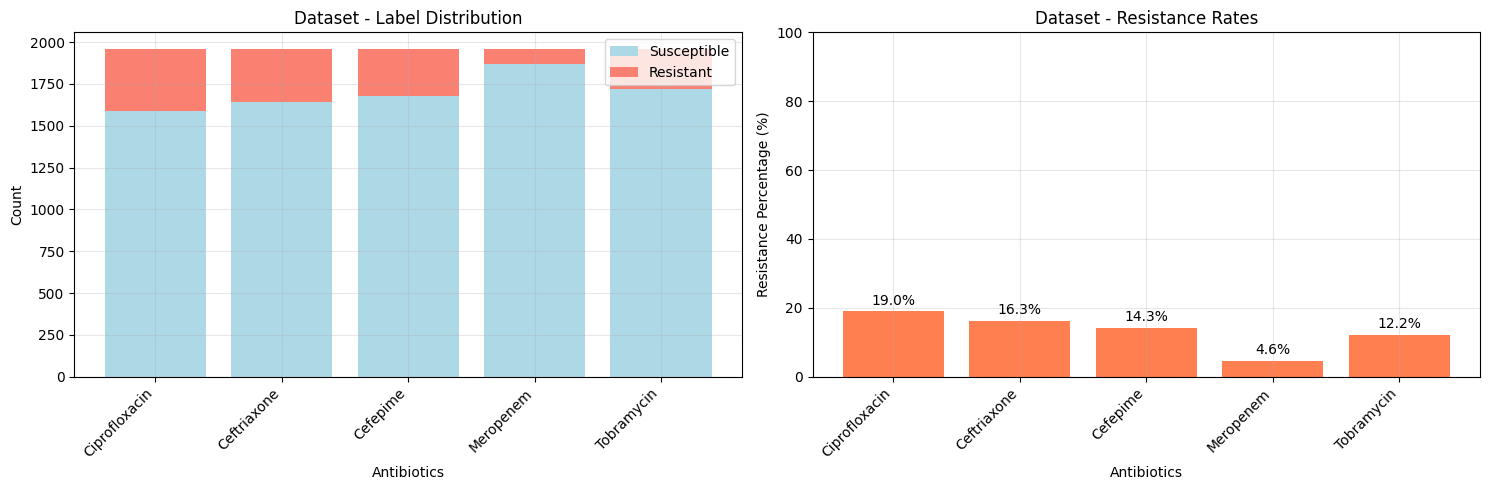

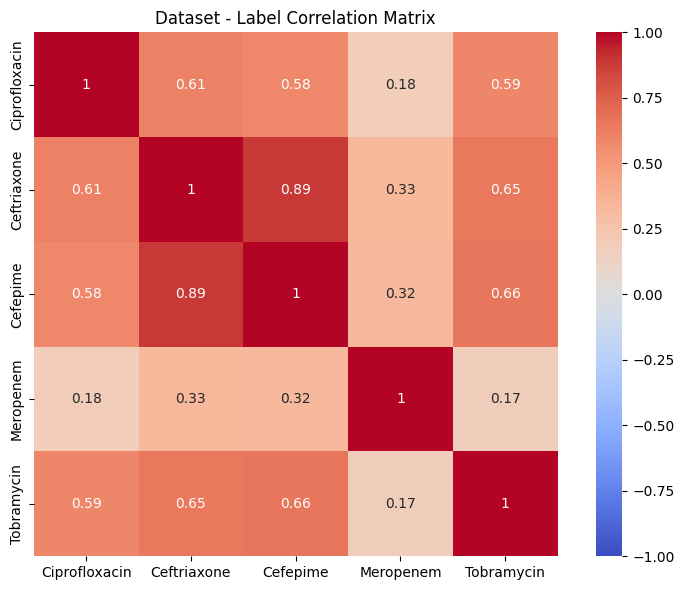


Dataset - Dataset Analysis:
Total samples: 276
Number of labels: 5
Label shape: (276, 5)

Dataset - Class Distribution:
Ciprofloxacin:
  Resistant: 49 (17.8%)
  Susceptible: 227 (82.2%)

Ceftriaxone:
  Resistant: 40 (14.5%)
  Susceptible: 236 (85.5%)

Cefepime:
  Resistant: 34 (12.3%)
  Susceptible: 242 (87.7%)

Meropenem:
  Resistant: 6 (2.2%)
  Susceptible: 270 (97.8%)

Tobramycin:
  Resistant: 28 (10.1%)
  Susceptible: 248 (89.9%)

Summary Table:
           Label  Resistant  Susceptible  Resistance %
0  Ciprofloxacin         49          227         17.75
1    Ceftriaxone         40          236         14.49
2       Cefepime         34          242         12.32
3      Meropenem          6          270          2.17
4     Tobramycin         28          248         10.14



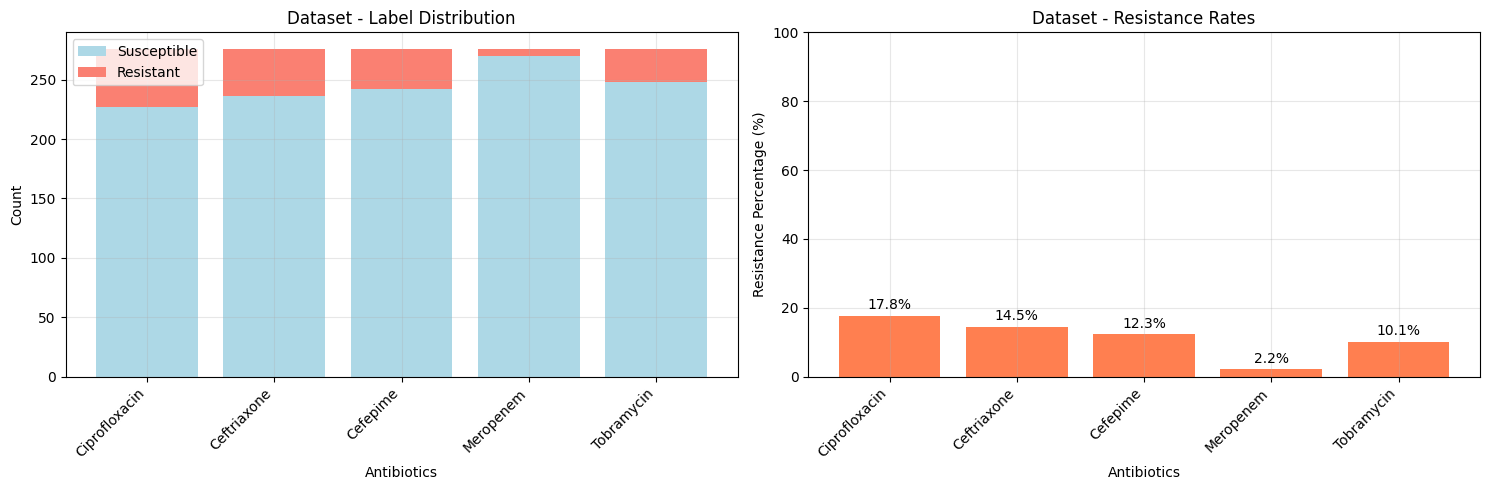

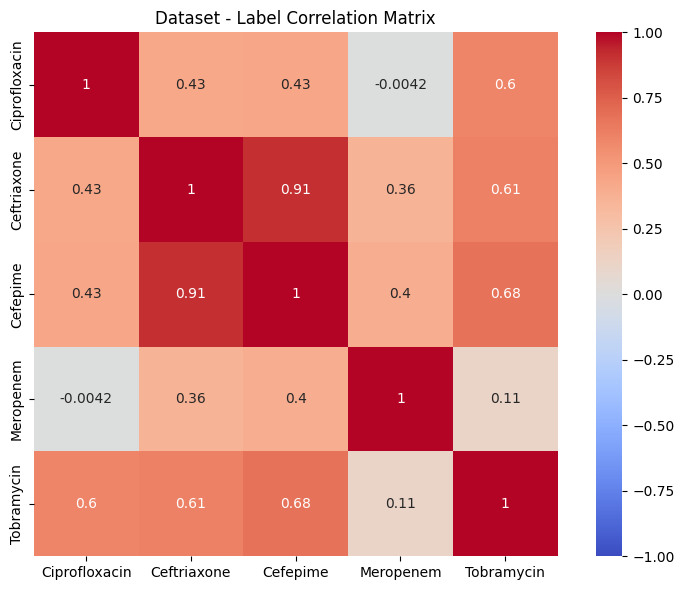


Dataset - Dataset Analysis:
Total samples: 559
Number of labels: 5
Label shape: (559, 5)

Dataset - Class Distribution:
Ciprofloxacin:
  Resistant: 97 (17.4%)
  Susceptible: 462 (82.6%)

Ceftriaxone:
  Resistant: 81 (14.5%)
  Susceptible: 478 (85.5%)

Cefepime:
  Resistant: 69 (12.3%)
  Susceptible: 490 (87.7%)

Meropenem:
  Resistant: 7 (1.3%)
  Susceptible: 552 (98.7%)

Tobramycin:
  Resistant: 64 (11.4%)
  Susceptible: 495 (88.6%)

Summary Table:
           Label  Resistant  Susceptible  Resistance %
0  Ciprofloxacin         97          462         17.35
1    Ceftriaxone         81          478         14.49
2       Cefepime         69          490         12.34
3      Meropenem          7          552          1.25
4     Tobramycin         64          495         11.45



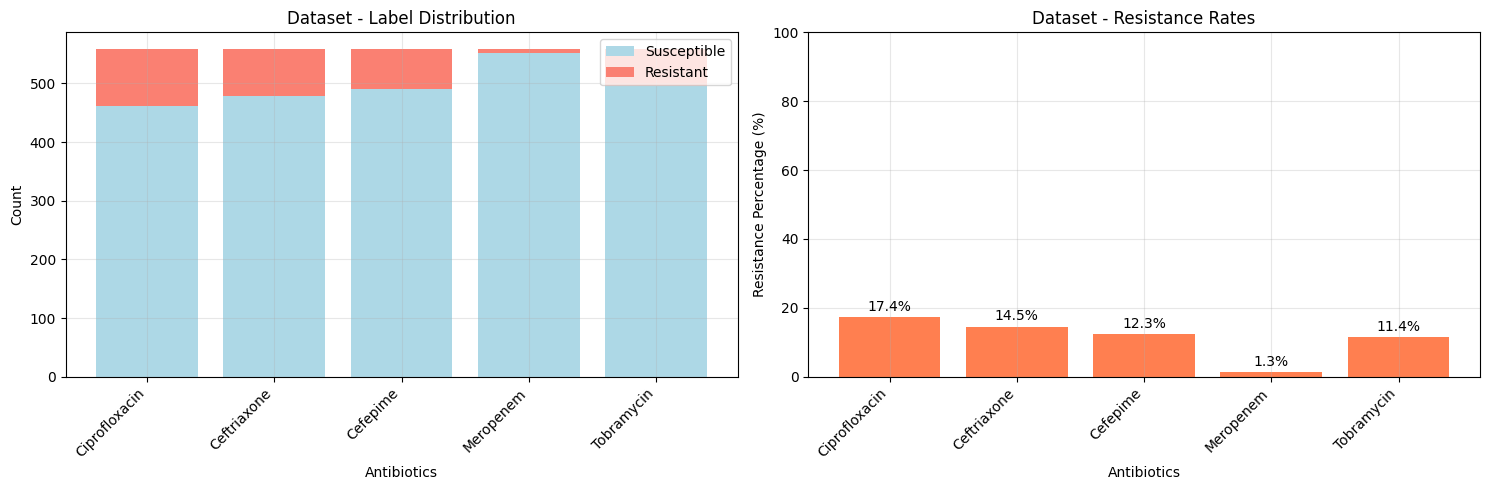

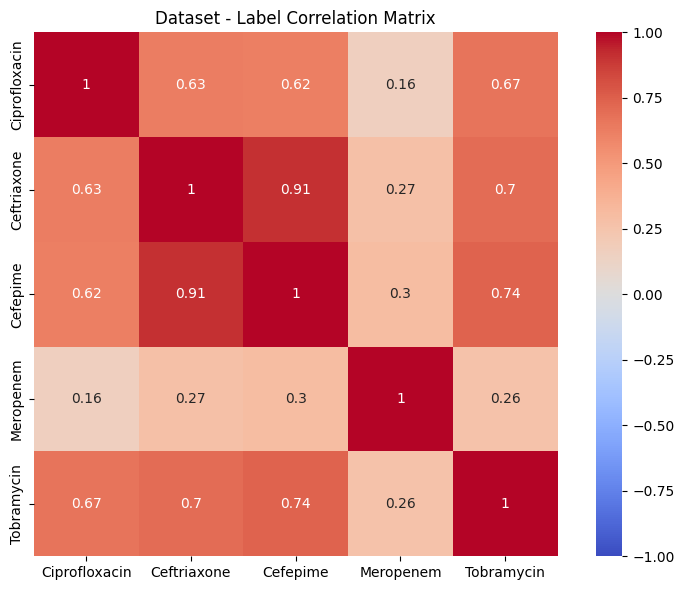

,Label,Resistant,Susceptible,Resistance %
0,Ciprofloxacin,97,462,17.35
1,Ceftriaxone,81,478,14.49
2,Cefepime,69,490,12.34
3,Meropenem,7,552,1.25
4,Tobramycin,64,495,11.45


In [20]:
analyze_pytorch_dataset(train_dataset, ['Ciprofloxacin', 'Ceftriaxone', 'Cefepime', 'Meropenem', 'Tobramycin'])
analyze_pytorch_dataset(val_dataset, ['Ciprofloxacin', 'Ceftriaxone', 'Cefepime', 'Meropenem', 'Tobramycin'])
analyze_pytorch_dataset(test_dataset, ['Ciprofloxacin', 'Ceftriaxone', 'Cefepime', 'Meropenem', 'Tobramycin'])

## **Training the model**

Our splits are ready, now we build the model 5 output heads and dropout of 0 using `MultiHeadCNN` and `BayesMultiHeadCNN` class. We train this model for 50 epochs using our class StandardExperimentRunner_bayesiansetup class

### **Loading the deterministic model weights deterministic** 

In [21]:
det_model = MultiHeadCNN(num_labels=5, dropout = 0)
state_dict = torch.load("/kaggle/input/kp-2015-2018-detmodel-seta/kp_best_model.pt")  
det_model.load_state_dict(state_dict)
print("Loaded pretrained deterministic weights")

Loaded pretrained deterministic weights


### **Now preparing bayesian model with last two layers as bayesian and loading the weights of deterministic model in deterministic backbone of bayesian network**

In [22]:
bayes_model = BayesMultiHeadCNN(bayesian_layers = 2, num_labels=5, dropout = 0)
pretrained_dict = det_model.state_dict()
model_dict = bayes_model.state_dict()
pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and "fc3" not in k and "head" not in k}
model_dict.update(pretrained_dict)
bayes_model.load_state_dict(model_dict)
print("Loaded deterministic backbone, Bayesian layers randomly initialized")

Loaded deterministic backbone, Bayesian layers randomly initialized


### **Freezing the deterministic part**

In [23]:
for name, param in bayes_model.named_parameters():
    if "fc3" not in name and "head" not in name:
        param.requires_grad = False
print("Frozen backbone, training only Bayesian layers")

Frozen backbone, training only Bayesian layers


### **Training the bayesian layers from scratch**

The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.


Epoch 1/50 | Train Loss: 0.5478 | Val Loss: 0.3673
 Best model saved.
Epoch 2/50 | Train Loss: 0.4297 | Val Loss: 0.3579
 Best model saved.
Epoch 3/50 | Train Loss: 0.3913 | Val Loss: 0.3229
 Best model saved.
Epoch 4/50 | Train Loss: 0.3596 | Val Loss: 0.3047
 Best model saved.
Epoch 5/50 | Train Loss: 0.3496 | Val Loss: 0.3068
Epoch 6/50 | Train Loss: 0.3423 | Val Loss: 0.3150
Epoch 7/50 | Train Loss: 0.3194 | Val Loss: 0.2911
 Best model saved.
Epoch 8/50 | Train Loss: 0.3289 | Val Loss: 0.2806
 Best model saved.
Epoch 9/50 | Train Loss: 0.2946 | Val Loss: 0.2958
Epoch 10/50 | Train Loss: 0.2878 | Val Loss: 0.2809
Epoch 11/50 | Train Loss: 0.3058 | Val Loss: 0.2775
 Best model saved.
Epoch 12/50 | Train Loss: 0.3049 | Val Loss: 0.2627
 Best model saved.
Epoch 13/50 | Train Loss: 0.2945 | Val Loss: 0.2766
Epoch 14/50 | Train Loss: 0.2886 | Val Loss: 0.2896
Epoch 15/50 | Train Loss: 0.3031 | Val Loss: 0.2857
Epoch 16/50 | Train Loss: 0.2781 | Val Loss: 0.2598
 Best model saved.
Epoch 

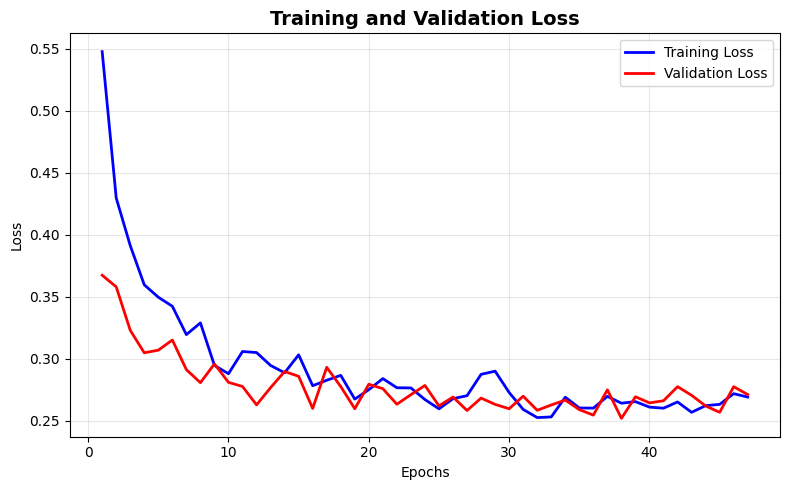


 Final Training Metrics:
Final Training Loss: 0.2690
Final Validation Loss: 0.2710
Best Validation Loss: 0.2518 (Epoch 38)


In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
runner = StandardExperimentRunner_bayesiansetup(bayes_model, train_dataset, val_dataset, device=device)

# Train the model
trained_model, train_losses, val_losses = runner.train(
        epochs=50,
        batch_size=64,
        lr=1e-4,
        weight_decay=0.0001,
        patience=9,
        kl_weight = 0.01,
        save_path="best_model.pt"
)

## **Evaluating**

Now we evaluate our trained model using our `evaluate_multilabel` utility


Per-Label Evaluation Metrics:

Ciprofloxacin:
  Balanced Accuracy: 0.6520
  AUROC:             0.7667
  AUPRC:             0.5326
  Weighted F1:       0.8401
  Mean variance:     0.0268
  Variance of var.:  0.0011
  TP mean Uncertainty:    0.0383
  TN mean Uncertainty:    0.0238
  FP mean Uncertainty:    0.0582
  FN mean Uncertainty:    0.0358

  TP std Uncertainty:    0.0334
  TN std Uncertainty:    0.0315
  FP std Uncertainty:    0.0367
  FN std Uncertainty:    0.0360

Ceftriaxone:
  Balanced Accuracy: 0.7293
  AUROC:             0.8693
  AUPRC:             0.7288
  Weighted F1:       0.9026
  Mean variance:     0.0158
  Variance of var.:  0.0006
  TP mean Uncertainty:    0.0202
  TN mean Uncertainty:    0.0135
  FP mean Uncertainty:    0.0653
  FN mean Uncertainty:    0.0311

  TP std Uncertainty:    0.0248
  TN std Uncertainty:    0.0213
  FP std Uncertainty:    0.0232
  FN std Uncertainty:    0.0320

Cefepime:
  Balanced Accuracy: 0.7144
  AUROC:             0.8495
  AUPRC:      

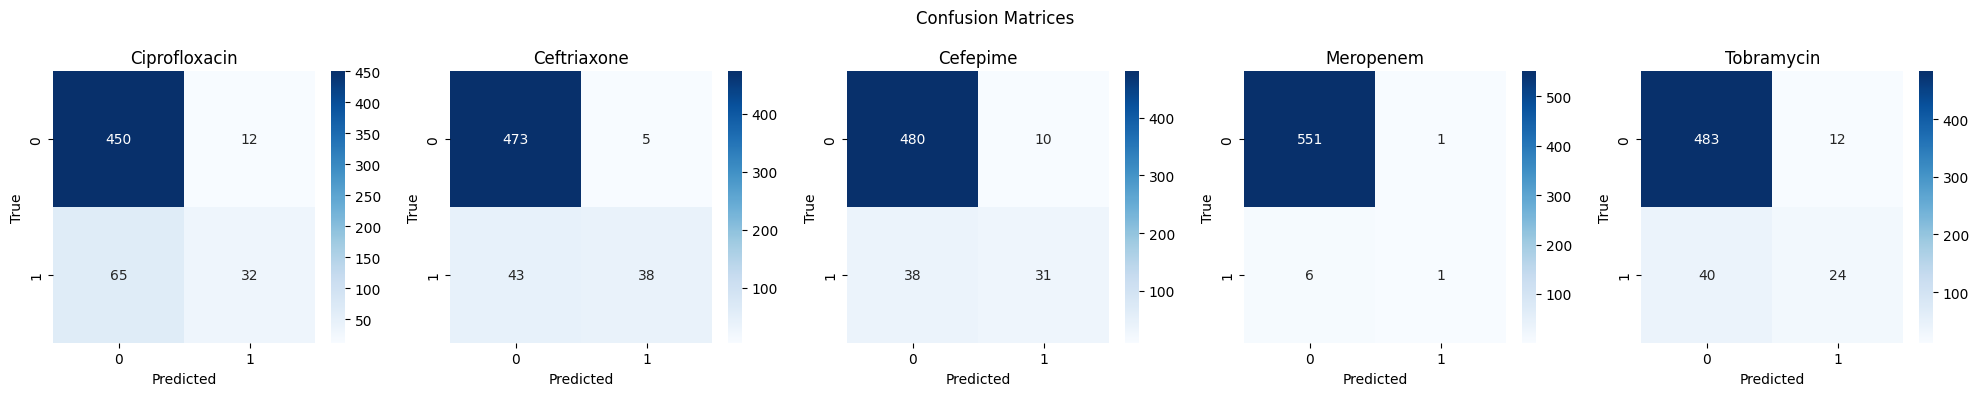


Per-Label Evaluation Metrics:

Ciprofloxacin:
  Balanced Accuracy: 0.6167
  AUROC:             0.7699
  AUPRC:             0.5176
  Weighted F1:       0.8179
  Mean variance:     0.0263
  Variance of var.:  0.0010
  TP mean Uncertainty:    0.0456
  TN mean Uncertainty:    0.0214
  FP mean Uncertainty:    0.0724
  FN mean Uncertainty:    0.0398

  TP std Uncertainty:    0.0277
  TN std Uncertainty:    0.0278
  FP std Uncertainty:    0.0279
  FN std Uncertainty:    0.0382

Ceftriaxone:
  Balanced Accuracy: 0.7489
  AUROC:             0.8689
  AUPRC:             0.7359
  Weighted F1:       0.9115
  Mean variance:     0.0179
  Variance of var.:  0.0007
  TP mean Uncertainty:    0.0253
  TN mean Uncertainty:    0.0151
  FP mean Uncertainty:    0.0493
  FN mean Uncertainty:    0.0399

  TP std Uncertainty:    0.0299
  TN std Uncertainty:    0.0238
  FP std Uncertainty:    0.0225
  FN std Uncertainty:    0.0419

Cefepime:
  Balanced Accuracy: 0.7299
  AUROC:             0.8463
  AUPRC:      

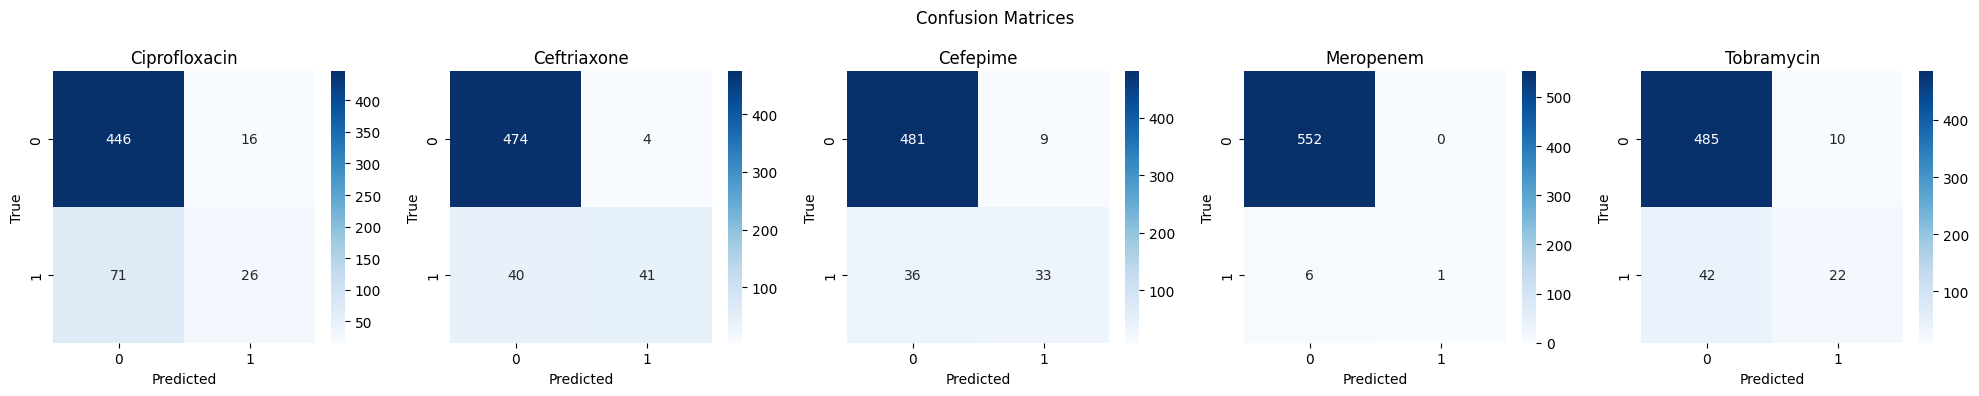


Per-Label Evaluation Metrics:

Ciprofloxacin:
  Balanced Accuracy: 0.6210
  AUROC:             0.7912
  AUPRC:             0.5489
  Weighted F1:       0.8235
  Mean variance:     0.0247
  Variance of var.:  0.0008
  TP mean Uncertainty:    0.0463
  TN mean Uncertainty:    0.0192
  FP mean Uncertainty:    0.0615
  FN mean Uncertainty:    0.0458

  TP std Uncertainty:    0.0404
  TN std Uncertainty:    0.0231
  FP std Uncertainty:    0.0324
  FN std Uncertainty:    0.0353

Ceftriaxone:
  Balanced Accuracy: 0.7242
  AUROC:             0.8830
  AUPRC:             0.7372
  Weighted F1:       0.9018
  Mean variance:     0.0114
  Variance of var.:  0.0004
  TP mean Uncertainty:    0.0269
  TN mean Uncertainty:    0.0083
  FP mean Uncertainty:    0.0528
  FN mean Uncertainty:    0.0277

  TP std Uncertainty:    0.0286
  TN std Uncertainty:    0.0155
  FP std Uncertainty:    0.0160
  FN std Uncertainty:    0.0303

Cefepime:
  Balanced Accuracy: 0.7279
  AUROC:             0.8422
  AUPRC:      

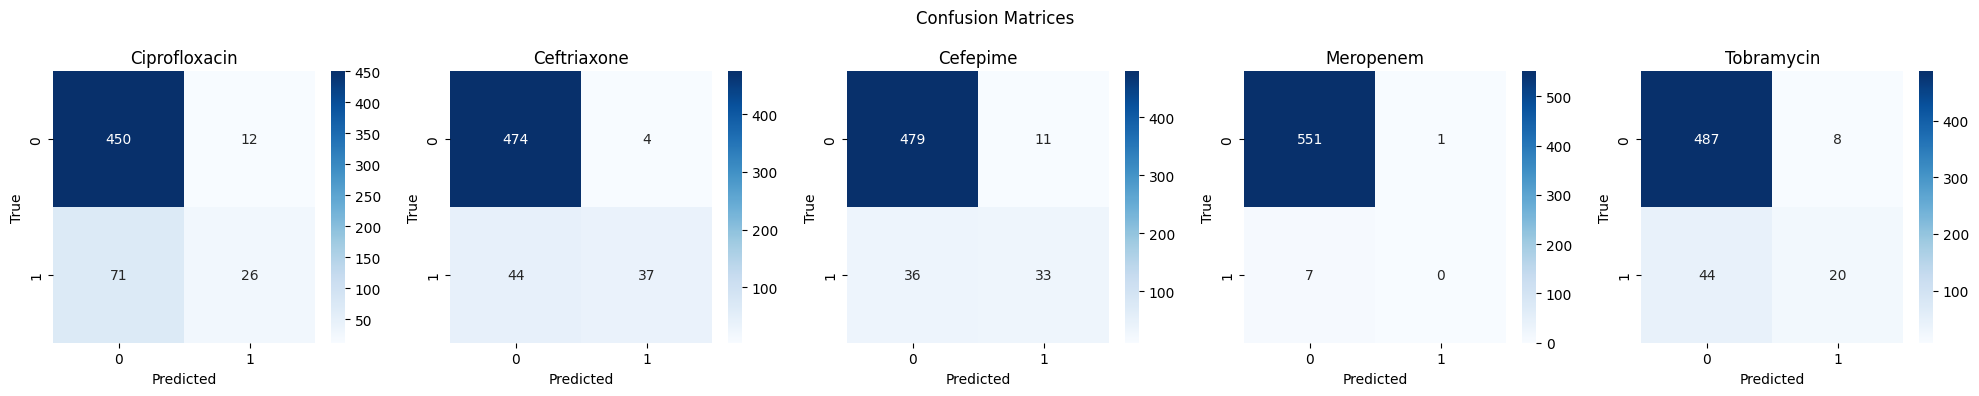


Per-Label Evaluation Metrics:

Ciprofloxacin:
  Balanced Accuracy: 0.6262
  AUROC:             0.7625
  AUPRC:             0.5342
  Weighted F1:       0.8264
  Mean variance:     0.0369
  Variance of var.:  0.0013
  TP mean Uncertainty:    0.0547
  TN mean Uncertainty:    0.0331
  FP mean Uncertainty:    0.0839
  FN mean Uncertainty:    0.0461

  TP std Uncertainty:    0.0392
  TN std Uncertainty:    0.0341
  FP std Uncertainty:    0.0283
  FN std Uncertainty:    0.0359

Ceftriaxone:
  Balanced Accuracy: 0.7345
  AUROC:             0.8798
  AUPRC:             0.7312
  Weighted F1:       0.9034
  Mean variance:     0.0123
  Variance of var.:  0.0004
  TP mean Uncertainty:    0.0198
  TN mean Uncertainty:    0.0096
  FP mean Uncertainty:    0.0523
  FN mean Uncertainty:    0.0301

  TP std Uncertainty:    0.0258
  TN std Uncertainty:    0.0150
  FP std Uncertainty:    0.0308
  FN std Uncertainty:    0.0327

Cefepime:
  Balanced Accuracy: 0.7155
  AUROC:             0.8424
  AUPRC:      

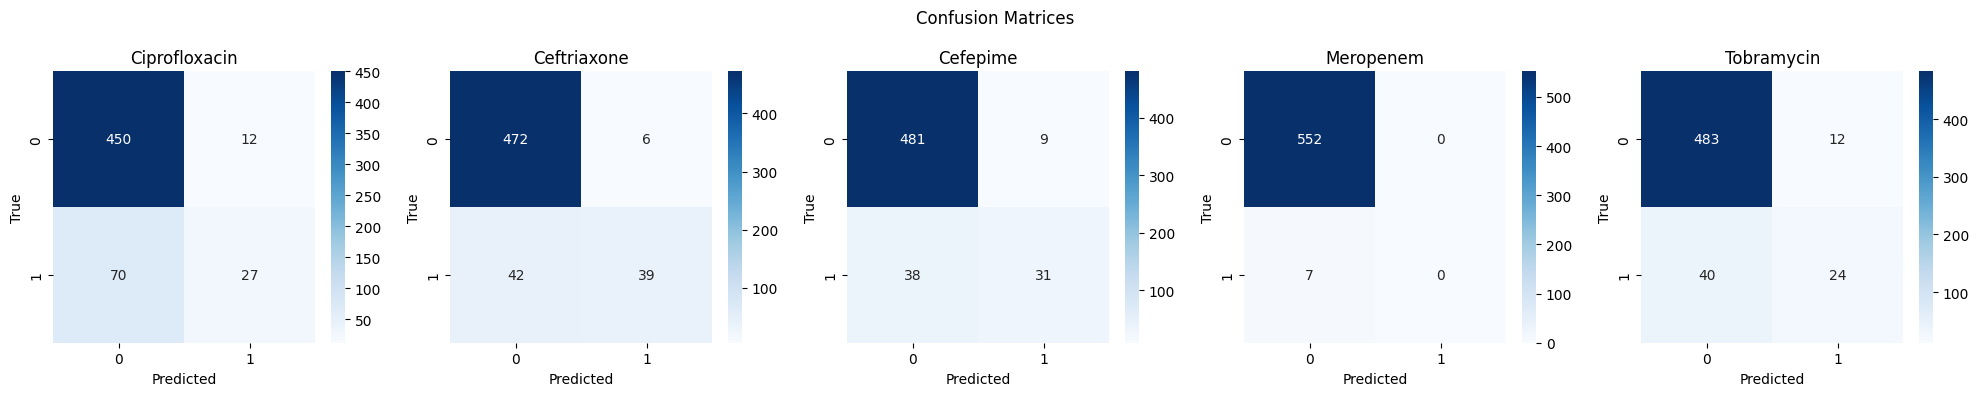


Per-Label Evaluation Metrics:

Ciprofloxacin:
  Balanced Accuracy: 0.6487
  AUROC:             0.7688
  AUPRC:             0.5296
  Weighted F1:       0.8357
  Mean variance:     0.0306
  Variance of var.:  0.0010
  TP mean Uncertainty:    0.0566
  TN mean Uncertainty:    0.0261
  FP mean Uncertainty:    0.0683
  FN mean Uncertainty:    0.0404

  TP std Uncertainty:    0.0413
  TN std Uncertainty:    0.0285
  FP std Uncertainty:    0.0237
  FN std Uncertainty:    0.0321

Ceftriaxone:
  Balanced Accuracy: 0.7170
  AUROC:             0.8741
  AUPRC:             0.7281
  Weighted F1:       0.8977
  Mean variance:     0.0132
  Variance of var.:  0.0004
  TP mean Uncertainty:    0.0338
  TN mean Uncertainty:    0.0092
  FP mean Uncertainty:    0.0693
  FN mean Uncertainty:    0.0322

  TP std Uncertainty:    0.0325
  TN std Uncertainty:    0.0150
  FP std Uncertainty:    0.0210
  FN std Uncertainty:    0.0293

Cefepime:
  Balanced Accuracy: 0.7227
  AUROC:             0.8558
  AUPRC:      

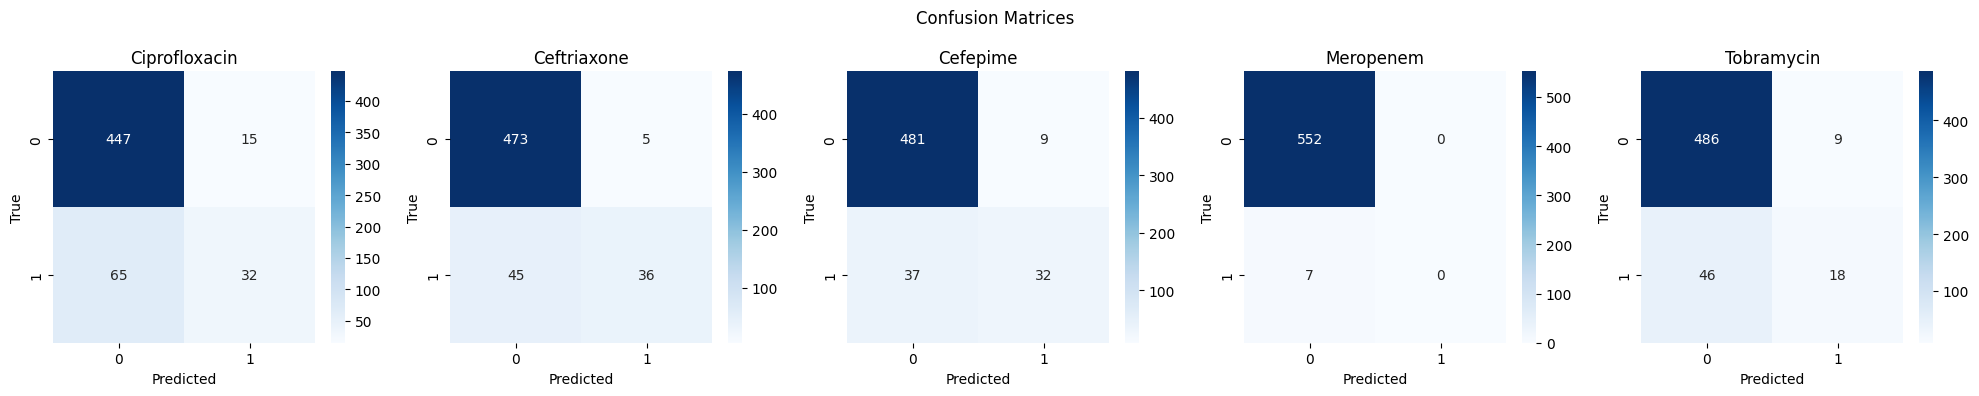

In [25]:
# Evaluate on test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
trained_model.to("cuda")
preds = evaluate_multilabel_bayesiansetup(trained_model, test_loader, antibiotics, device="cuda", file = "kp_2015_2018_lasttwolayerbayes_seta_run1.json")
preds = evaluate_multilabel_bayesiansetup(trained_model, test_loader, antibiotics, device="cuda", file = "kp_2015_2018_lasttwolayerbayes_seta_run2.json")
preds = evaluate_multilabel_bayesiansetup(trained_model, test_loader, antibiotics, device="cuda", file = "kp_2015_2018_lasttwolayerbayes_seta_run3.json")
preds = evaluate_multilabel_bayesiansetup(trained_model, test_loader, antibiotics, device="cuda", file = "kp_2015_2018_lasttwolayerbayes_seta_run4.json")
preds = evaluate_multilabel_bayesiansetup(trained_model, test_loader, antibiotics, device="cuda", file = "kp_2015_2018_lasttwolayerbayes_seta_run5.json")

## **Plotting UMAPS with and without error anotation**

In [26]:
features, labels = extract_features(trained_model, test_loader, device)

# Convert to numpy
features_np = features.numpy()
labels_np = labels.numpy()

# list of label names
label_names = ['Ciprofloxacin', 'Ceftriaxone', 'Cefepime', 'Meropenem', 'Tobramycin']
# Plot UMAPs
plot_umap(features_np, labels_np, label_names=label_names)
plot_umap_with_error(features_np, labels_np, preds, label_names=label_names)

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Saved: umap_figures/umap_Ciprofloxacin_half.png
Saved: umap_figures/umap_Ciprofloxacin_full.png
Saved: umap_figures/umap_Ceftriaxone_half.png
Saved: umap_figures/umap_Ceftriaxone_full.png
Saved: umap_figures/umap_Cefepime_half.png
Saved: umap_figures/umap_Cefepime_full.png
Saved: umap_figures/umap_Meropenem_half.png
Saved: umap_figures/umap_Meropenem_full.png
Saved: umap_figures/umap_Tobramycin_half.png
Saved: umap_figures/umap_Tobramycin_full.png


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Saved: umap_figures_error/umap_Ciprofloxacin_half_error.png
Saved: umap_figures_error/umap_Ciprofloxacin_full_error.png
Saved: umap_figures_error/umap_Ceftriaxone_half_error.png
Saved: umap_figures_error/umap_Ceftriaxone_full_error.png
Saved: umap_figures_error/umap_Cefepime_half_error.png
Saved: umap_figures_error/umap_Cefepime_full_error.png
Saved: umap_figures_error/umap_Meropenem_half_error.png
Saved: umap_figures_error/umap_Meropenem_full_error.png
Saved: umap_figures_error/umap_Tobramycin_half_error.png
Saved: umap_figures_error/umap_Tobramycin_full_error.png
